# Representation Spaces in Neural Networks

Key paradox:

All hidden states live in the same vector space ℝᵈ  
Yet we talk about *different representation spaces* across layers.

Goal of this notebook:
1) Show how the same vectors can change meaning
2) Show how deeper layers make abstract concepts linearly separable
3) Build intuition for latent representations

<details>

**Big design principle**

# Big design principle

For this topic, the audience must *see vectors change meaning while staying in the same ℝᵈ*.

So the best illustrations are:

• 2-D toy embeddings
• simple linear probes
• progressive basis changes
• separability emerging across layers

Everything should look like little ML experiments.

---

# Illustration 1 — “Same vector space, different basis”

## Goal

Show that the same points can represent totally different concepts after a basis rotation.

## Notebook demo idea

1. Create 2D toy embeddings:

* Points represent words
* X-axis = animalness
* Y-axis = speed

Plot words like:

```
cat, dog, car, turtle, rocket
```

2. Apply a random invertible matrix:
   [
   h' = A h
   ]

Plot transformed points.

3. Show that:

* Distances preserved? No (unless orthogonal)
* But linear separability changes dramatically.

### Key teaching moment

Add a linear classifier line:

```
animal vs vehicle
```

Before transform → hard to separate
After transform → easy to separate

**Message:** The *coordinates* changed, but the *information* didn’t.

---

# Illustration 2 — Linear probe emergence (the killer demo)

This one is GOLD for lectures.

## Goal

Show how deeper layers make abstract concepts linearly separable.

### Build synthetic dataset

Each point has hidden factors:

| feature | value             |
| ------- | ----------------- |
| shape   | square/circle     |
| color   | red/blue          |
| label   | XOR(shape, color) |

Important:
XOR is **not linearly separable**.

### Build tiny neural network

2–3 hidden layers (small MLP).

Train it.

Then at each layer:

1. Extract hidden activations
2. Train a *linear classifier probe*
3. Measure accuracy

Plot probe accuracy vs layer depth.

Expected result:

```
Layer 0: 50%
Layer 1: 65%
Layer 2: 85%
Layer 3: 99%
```

### Key teaching moment

> Deep networks make nonlinear concepts **linear in later layers**.

This directly explains “different representation spaces”.

---

# Illustration 3 — Same vector, different decoder

This is a very intuitive one.

## Idea

Take one fixed vector `v`.

Define two linear decoders:

```
decoder_A(v) → animalness
decoder_B(v) → sentiment
```

Show that the same vector can be:

* strongly positive sentiment
* strongly “animal” concept

Because meaning comes from the **decoder**.

You can literally show:

```
w_animal^T v = 4.3
w_sentiment^T v = -2.1
```

Big takeaway:

> Vectors don’t have meaning alone — meaning lives in the probe.

---

# Illustration 4 — Geometry evolving across layers

This mimics real LLM behavior.

## Steps

Generate a small “sentence dataset”:

Animals: dog, cat, fox
Objects: car, chair, phone

Create toy embeddings.

Then simulate “layers” by progressively applying matrices that:

Layer 1 → cluster by syntax (noun vs verb)
Layer 2 → cluster by semantic category
Layer 3 → cluster by task relevance

Plot 3 side-by-side scatter plots.

Label them:

```
Embedding space
Syntactic space
Semantic space
Task space
```

This visually nails the idea of representation spaces.

---

# Illustration 5 — Distances changing meaning

Show cosine similarity matrices across layers.

Heatmaps:

Layer 0 similarity:

```
cat ~ car
dog ~ chair
```

Layer L similarity:

```
cat ~ dog
car ~ chair
```

Audience LOVES this one because it mirrors real LLM probing papers.

---

# Illustration 6 — Compiler pipeline analogy (visual)

Make a simple flow diagram in markdown:

```
tokens → syntax → semantics → task → logits
```

Then attach your plots under each stage.

This ties all experiments into one narrative.

---

# Suggested notebook structure

This flows really nicely:

### Section 1 — The paradox

Text explanation + rotation demo

### Section 2 — Linear probes

XOR probe experiment

### Section 3 — Meaning comes from decoders

Single-vector multi-decoder demo

### Section 4 — Representation evolution

Progressive clustering plots + similarity heatmaps

### Section 5 — Final takeaway

Short markdown summary.

---

# If you want ONE “hero demo”

Do this combo:

1. Train tiny MLP on XOR-like data
2. Probe linear separability at each layer
3. Visualize embeddings per layer

This single notebook can carry the whole lecture.

---

If you'd like, I can help you write the actual notebook cells (numpy/sklearn/matplotlib) step-by-step. That would translate directly into runnable content.

</details>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)
np.random.seed(0)

# PART 1 — SAME SPACE, DIFFERENT BASIS

## 1) Same vector space, different basis

We start with 2-D "word embeddings":

```
x-axis = animalness  
y-axis = speed
```

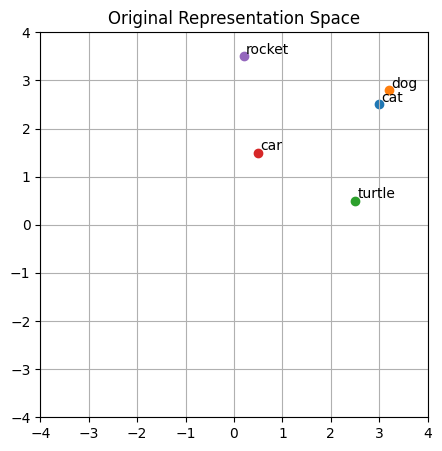

In [2]:
# Toy Embedding

words = ["cat","dog","turtle","car","rocket"]

emb = np.array([
    [3.0, 2.5],   # cat
    [3.2, 2.8],   # dog
    [2.5, 0.5],   # turtle
    [0.5, 1.5],   # car
    [0.2, 3.5],   # rocket
])

def plot_points(points, title):
    plt.figure(figsize=(5,5))
    for i,w in enumerate(words):
        plt.scatter(points[i,0], points[i,1])
        plt.text(points[i,0]+0.05, points[i,1]+0.05, w)
    plt.title(title)
    plt.xlim(-4,4)
    plt.ylim(-4,4)
    plt.grid()
    plt.show()

plot_points(emb, "Original Representation Space")

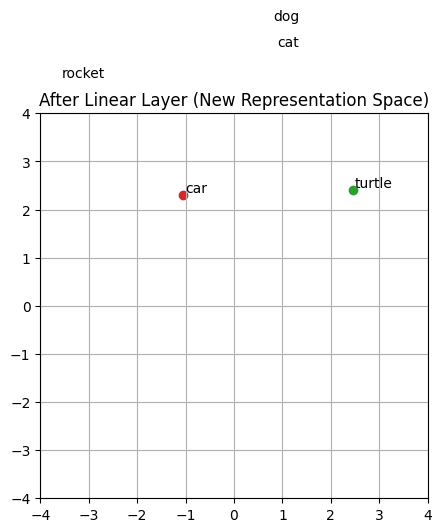

In [3]:
# CELL 5 — Random linear transform

A = np.array([[1.2, -1.1],
              [0.7,  1.3]])

emb2 = emb @ A.T
plot_points(emb2, "After Linear Layer (New Representation Space)")

# PART 2 — MEANING COMES FROM DECODERS

## 2) Meaning comes from linear decoders

Vectors don't have meaning by themselves.  
Meaning = vector + linear probe.

In [4]:
# CELL 7 — Two decoders

v = torch.tensor([1.5, -0.5])  # one vector

w_animal = torch.tensor([1.0, 0.2])
w_sentiment = torch.tensor([-0.5, 1.2])

animal_score = torch.dot(v, w_animal)
sentiment_score = torch.dot(v, w_sentiment)

animal_score, sentiment_score

(tensor(1.4000), tensor(-1.3500))

# PART 3 — THE HERO DEMO: LINEAR SEPARABILITY EMERGES

## 3) Deep networks make nonlinear concepts linear

We create a dataset where the label is XOR of two hidden factors.

This problem is **not linearly separable** in input space.

In [5]:
# CELL 9 — Create XOR dataset

N = 1000

x1 = np.random.choice([-1,1], N)
x2 = np.random.choice([-1,1], N)

X = np.stack([x1, x2], axis=1).astype(np.float32)
y = ((x1 * x2) == -1).astype(np.float32)  # XOR

X_torch = torch.tensor(X)
y_torch = torch.tensor(y).unsqueeze(1)

In [6]:
# CELL 10 — Visualize input space

model = nn.Sequential(
    nn.Linear(2,8),
    nn.Tanh(),
    nn.Linear(8,8),
    nn.Tanh(),
    nn.Linear(8,1),
    nn.Sigmoid()
)

opt = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

for epoch in range(2000):
    pred = model(X_torch)
    loss = loss_fn(pred, y_torch)
    opt.zero_grad()
    loss.backward()
    opt.step()

loss.item()

0.00019922584760934114

In [7]:
# CELL 12 — Extract hidden activations

def get_layer_outputs(model, X):
    outputs = []
    x = X
    for layer in model:
        x = layer(x)
        if isinstance(layer, nn.Tanh):
            outputs.append(x.detach().numpy())
    return outputs

layers = get_layer_outputs(model, X_torch)
len(layers)

2

In [8]:
# CELL 13 — Linear probe function

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def probe_accuracy(features, labels):
    clf = LogisticRegression().fit(features, labels)
    preds = clf.predict(features)
    return accuracy_score(labels, preds)

In [9]:
# CELL 14 — Probe each layer

acc_input = probe_accuracy(X, y)
acc_l1 = probe_accuracy(layers[0], y)
acc_l2 = probe_accuracy(layers[1], y)

acc_input, acc_l1, acc_l2

(0.523, 1.0, 1.0)

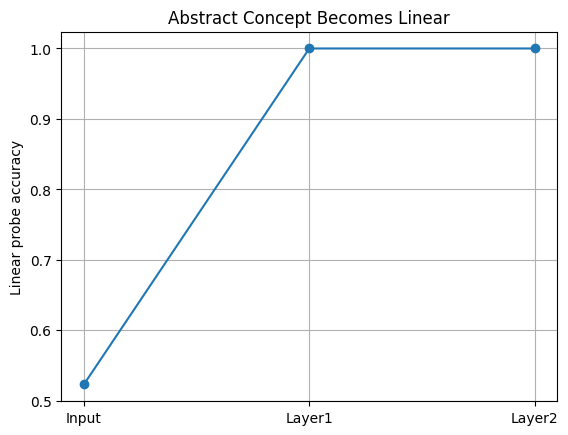

In [10]:
# CELL 15 — Plot probe accuracy vs depth

plt.plot([0,1,2], [acc_input, acc_l1, acc_l2], marker='o')
plt.xticks([0,1,2], ["Input","Layer1","Layer2"])
plt.ylabel("Linear probe accuracy")
plt.title("Abstract Concept Becomes Linear")
plt.grid()
plt.show()

# PART 4 — VISUALIZE REPRESENTATION EVOLUTION

## Final takeaway

All layers live in the same ℝᵈ.

But each layer:
• Rotates the coordinate system  
• Makes new features linearly accessible  
• Prepares representations for the next computation

A *representation space* is:
> The coordinate system in which useful features become linear.